In [53]:
# Importando as bibliotecas essenciais
import sys
import os
import pandas as pd
from sqlalchemy import text
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

sys.path.append("..")
from config import get_engine, PROCESSED_DATA_DIR, get_logger

logger = get_logger("03_analise_preditiva")
logger.info("Iniciando o pipeline de análise preditiva...")

21:38:25 | INFO     | 03_analise_preditiva | Iniciando o pipeline de análise preditiva...


In [54]:
# Extraindo a série mensal de queimadas.
query = """
    SELECT
        DATE_FORMAT(data_hora, '%Y-%m-01') AS ds,
        COUNT(*) AS y
    FROM fato_queimadas
    GROUP BY DATE_FORMAT(data_hora, '%Y-%m-01')
    ORDER BY ds;
"""

# Extraindo os dados do MySQL
try:
    engine = get_engine(database="db_queimadas")
    logger.info("Extraindo dados da tabela fato_queimadas...")
    with engine.connect() as conn:
        df_temporal = pd.read_sql_query(text(query), conn)
except Exception as e:
    logger.error(f"Falha ao extrair dados do MySQL: {e}")
    raise

# Validando se os dados foram carregados corretamente
if df_temporal.empty:
    raise ValueError("Nenhum dado retornado de fato_queimadas. Verifique se a carga (notebook 02) foi executada.")

df_temporal["ds"] = pd.to_datetime(df_temporal["ds"])
logger.info(f"Dados históricos carregados: {len(df_temporal)} meses com ao menos 1 registro.")

21:38:25 | INFO     | 03_analise_preditiva | Extraindo dados da tabela fato_queimadas...
21:38:27 | INFO     | 03_analise_preditiva | Dados históricos carregados: 67 meses com ao menos 1 registro.


In [55]:
# Preenchendo os meses ausentes com y=0 
calendario_completo = pd.DataFrame({
    "ds": pd.date_range(start=df_temporal["ds"].min(), end=df_temporal["ds"].max(), freq="MS")
})

df_temporal_completo = calendario_completo.merge(df_temporal, on="ds", how="left")
n_meses_preenchidos = df_temporal_completo["y"].isna().sum()
df_temporal_completo["y"] = df_temporal_completo["y"].fillna(0)

if n_meses_preenchidos > 0:
    logger.warning(
        f"{n_meses_preenchidos} mes(es) sem nenhum registro foram preenchidos com y=0: "
        f"{df_temporal_completo.loc[df_temporal_completo['y'] == 0, 'ds'].dt.strftime('%Y-%m').tolist()}"
    )
else:
    logger.info("Nenhum mês ausente — série já estava completa.")

df_temporal = df_temporal_completo

21:38:27 | INFO     | 03_analise_preditiva | Nenhum mês ausente — série já estava completa.


In [56]:
# Inicializando e treinando o modelo Prophet.
df_temporal["pos_politica_fogo"] = (df_temporal["ds"] >= "2024-07-01").astype(int)

logger.info("Treinando o modelo Prophet (crescimento logístico, sazonalidade anual)...")
try:
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.01,
        changepoint_range=0.7,
    )
    model.add_regressor("pos_politica_fogo")
    model.fit(df_temporal)
except Exception as e:
    logger.error(f"Falha ao treinar o modelo Prophet: {e}")
    raise

21:38:27 | INFO     | 03_analise_preditiva | Treinando o modelo Prophet (crescimento logístico, sazonalidade anual)...
21:38:27 - cmdstanpy - INFO - Chain [1] start processing
21:38:27 - cmdstanpy - INFO - Chain [1] done processing


In [57]:
# Criando as datas futuras para previsão (próximos 12 meses)
logger.info("Projetando os próximos 12 meses...")
future = model.make_future_dataframe(periods=12, freq="MS")
future["pos_politica_fogo"] = (future["ds"] >= "2024-07-01").astype(int)

forecast = model.predict(future)

# Garantindo que as previsões não sejam negativas
for col in ["yhat", "yhat_lower", "yhat_upper"]:
    forecast[col] = forecast[col].clip(lower=0)

21:38:27 | INFO     | 03_analise_preditiva | Projetando os próximos 12 meses...


In [58]:
# Avaliando o modelo com cross-validation
try:
    df_cv = cross_validation(model, initial="730 days", period="90 days", horizon="90 days")
    df_metrics = performance_metrics(df_cv)
    logger.info("Validação do modelo (médias das métricas):")
    logger.info(f"  MAE  médio: {df_metrics['mae'].mean():.2f}")
    logger.info(f"  RMSE médio: {df_metrics['rmse'].mean():.2f}")
    logger.info(f"  MAPE médio: {df_metrics['mape'].mean():.2%}")
except Exception as e:
    logger.warning(
        f"Cross-validation não pôde ser executada (provavelmente histórico curto demais "
        f"para os parâmetros initial/horizon usados): {e}"
    )

  0%|          | 0/14 [00:00<?, ?it/s]21:38:27 - cmdstanpy - INFO - Chain [1] start processing
21:38:27 - cmdstanpy - INFO - Chain [1] done processing
  7%|▋         | 1/14 [00:00<00:01,  7.26it/s]21:38:27 - cmdstanpy - INFO - Chain [1] start processing
21:38:27 - cmdstanpy - INFO - Chain [1] done processing
 14%|█▍        | 2/14 [00:00<00:01,  7.47it/s]21:38:28 - cmdstanpy - INFO - Chain [1] start processing
21:38:28 - cmdstanpy - INFO - Chain [1] done processing
 21%|██▏       | 3/14 [00:00<00:01,  6.78it/s]21:38:28 - cmdstanpy - INFO - Chain [1] start processing
21:38:28 - cmdstanpy - INFO - Chain [1] done processing
 29%|██▊       | 4/14 [00:00<00:01,  6.72it/s]21:38:28 - cmdstanpy - INFO - Chain [1] start processing
21:38:28 - cmdstanpy - INFO - Chain [1] done processing
 36%|███▌      | 5/14 [00:00<00:01,  6.89it/s]21:38:28 - cmdstanpy - INFO - Chain [1] start processing
21:38:28 - cmdstanpy - INFO - Chain [1] done processing
 43%|████▎     | 6/14 [00:00<00:01,  7.12it/s]21:38:28

In [59]:
# Salvando os resultados da previsão para uso no Power BI
caminho_previsao = os.path.join(PROCESSED_DATA_DIR, "previsao_queimadas.csv")
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].to_csv(caminho_previsao, index=False)
logger.info(f"Previsão salva com sucesso em: {caminho_previsao}")

21:38:29 | INFO     | 03_analise_preditiva | Previsão salva com sucesso em: /home/eric/projetos/Analise-Queimadas-Brasil/data/processed/previsao_queimadas.csv


21:38:29 | INFO     | 03_analise_preditiva | Renderizando gráficos da previsão...
21:38:30 | INFO     | 03_analise_preditiva | Gráficos salvos em data/processed/.


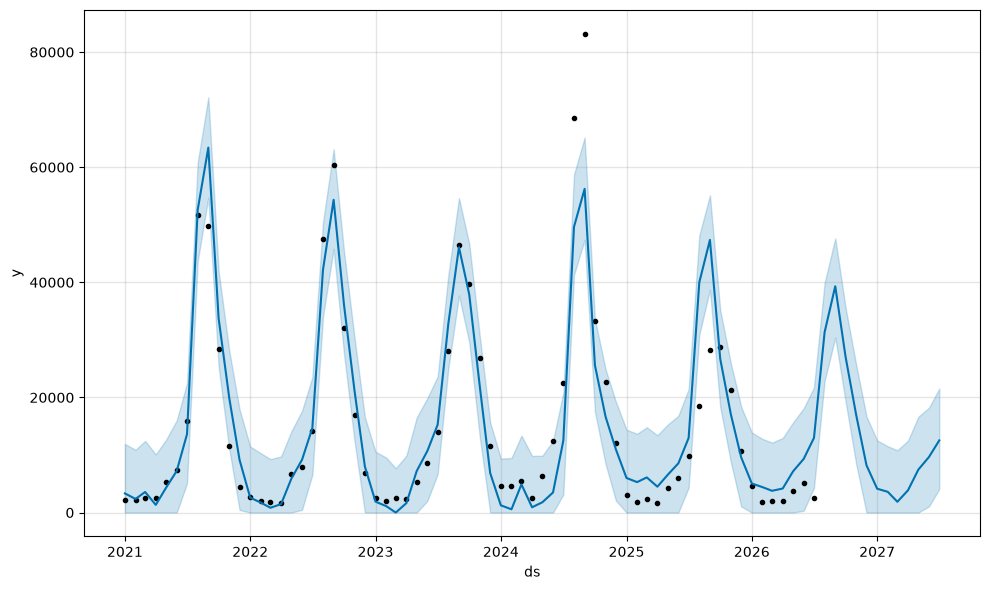

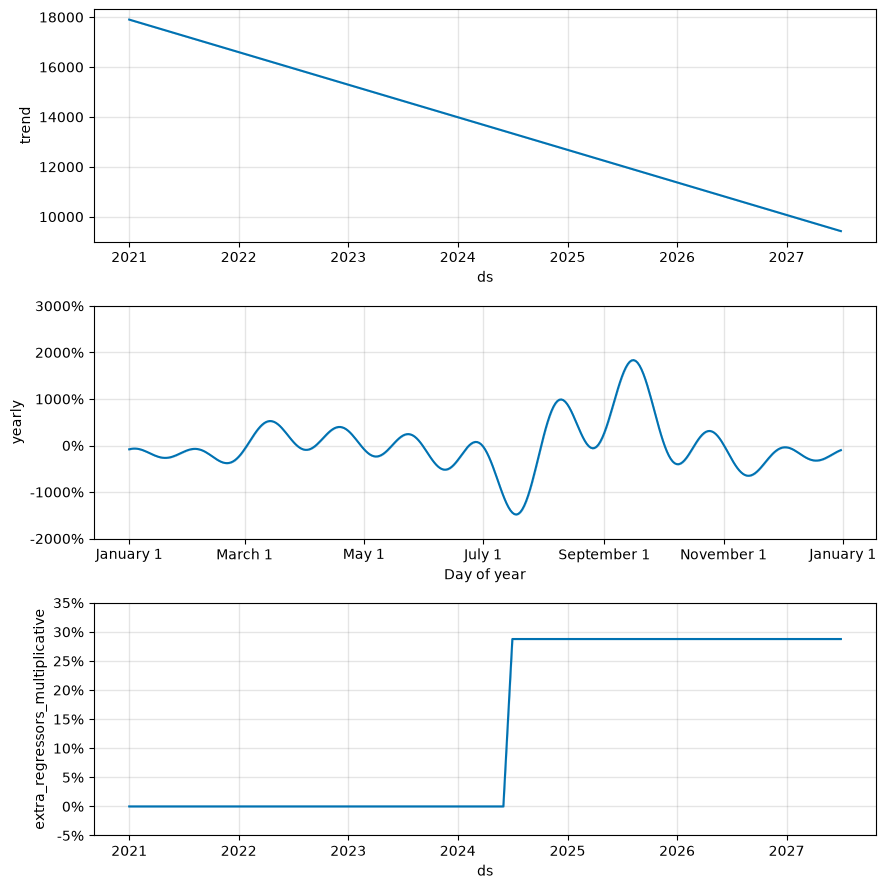

In [60]:
# Renderizando e salvando os gráficos de tendência e previsão
logger.info("Renderizando gráficos da previsão...")

fig_forecast = model.plot(forecast)
fig_forecast.savefig(os.path.join(PROCESSED_DATA_DIR, "grafico_previsao.png"), dpi=150, bbox_inches="tight")

fig_components = model.plot_components(forecast)
fig_components.savefig(os.path.join(PROCESSED_DATA_DIR, "grafico_componentes.png"), dpi=150, bbox_inches="tight")

logger.info("Gráficos salvos em data/processed/.")